In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df = pd.read_csv('retail_sales_dataset.csv') 
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


--- Dataset Head ---
   Transaction ID        Date Customer ID  Gender  Age Product Category  \
0               1  2023-11-24     CUST001    Male   34           Beauty   
1               2  2023-02-27     CUST002  Female   26         Clothing   
2               3  2023-01-13     CUST003    Male   50      Electronics   
3               4  2023-05-21     CUST004    Male   37         Clothing   
4               5  2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  

--- Dataset Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 

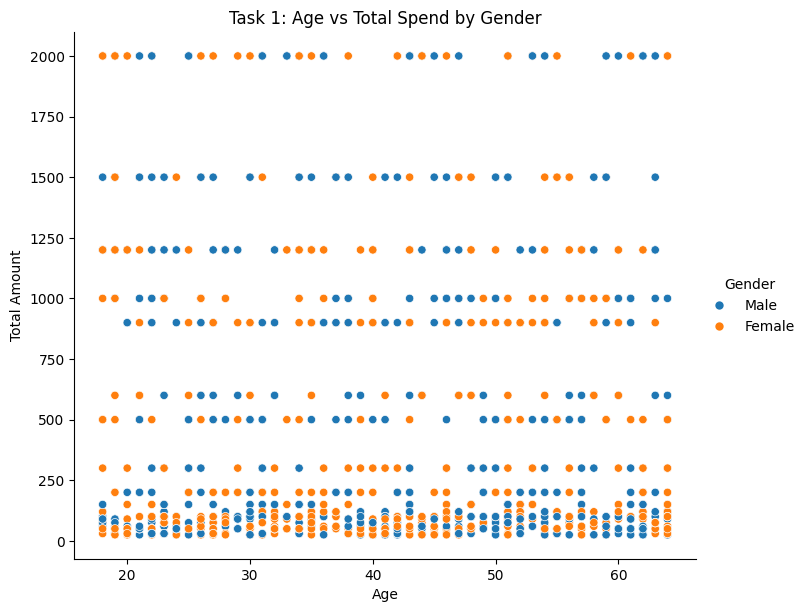

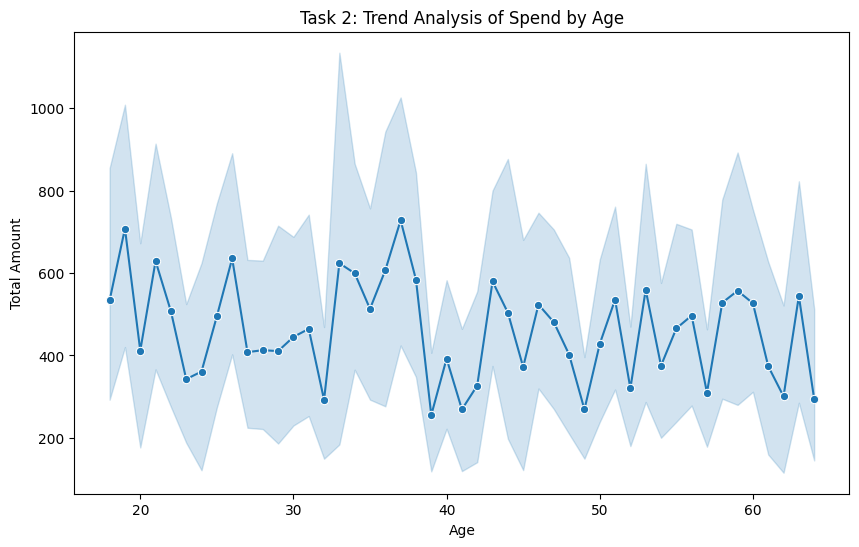

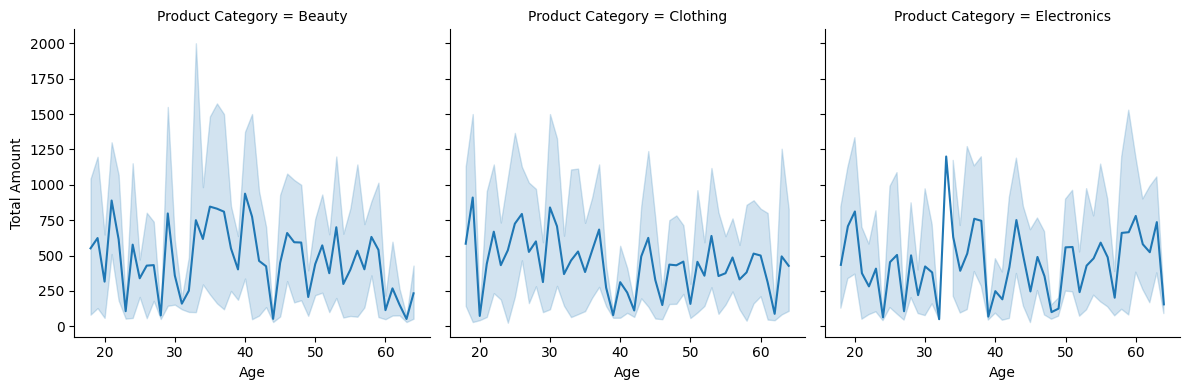

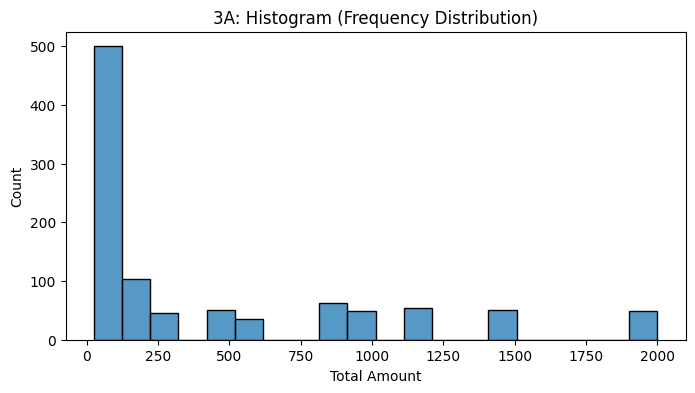

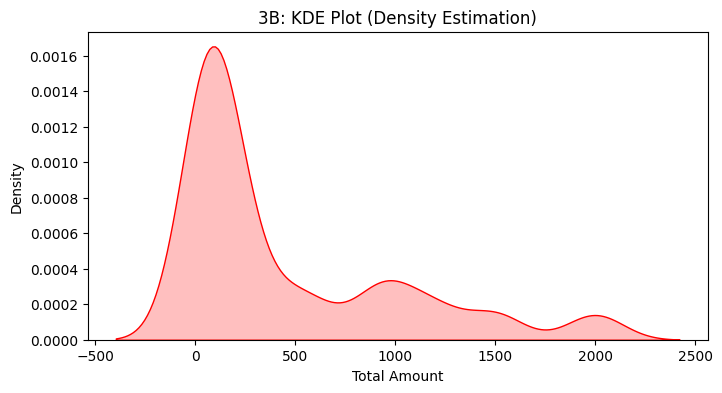

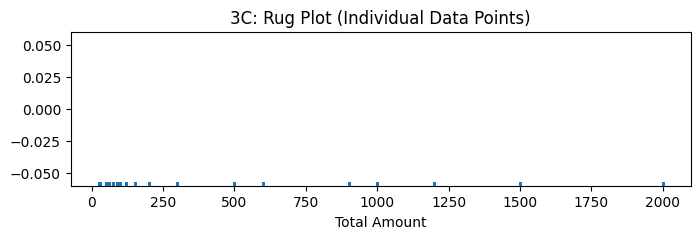

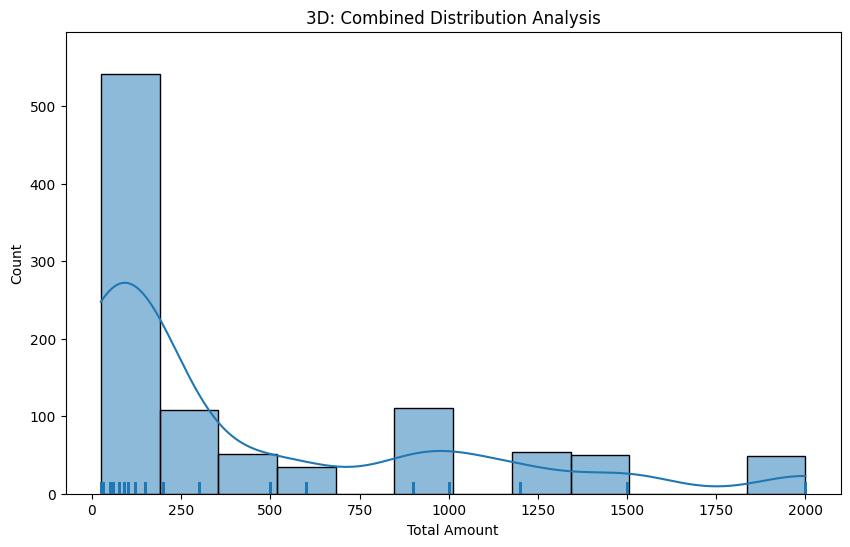

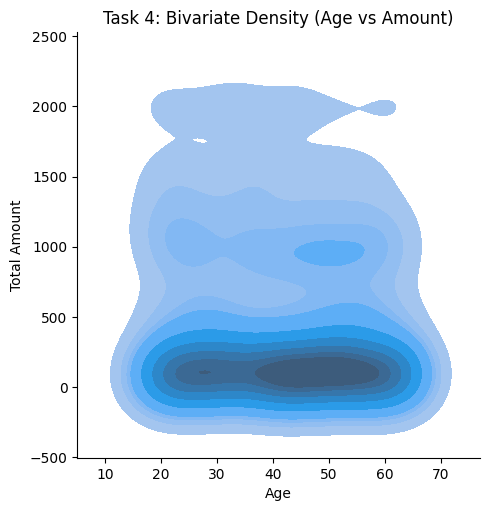

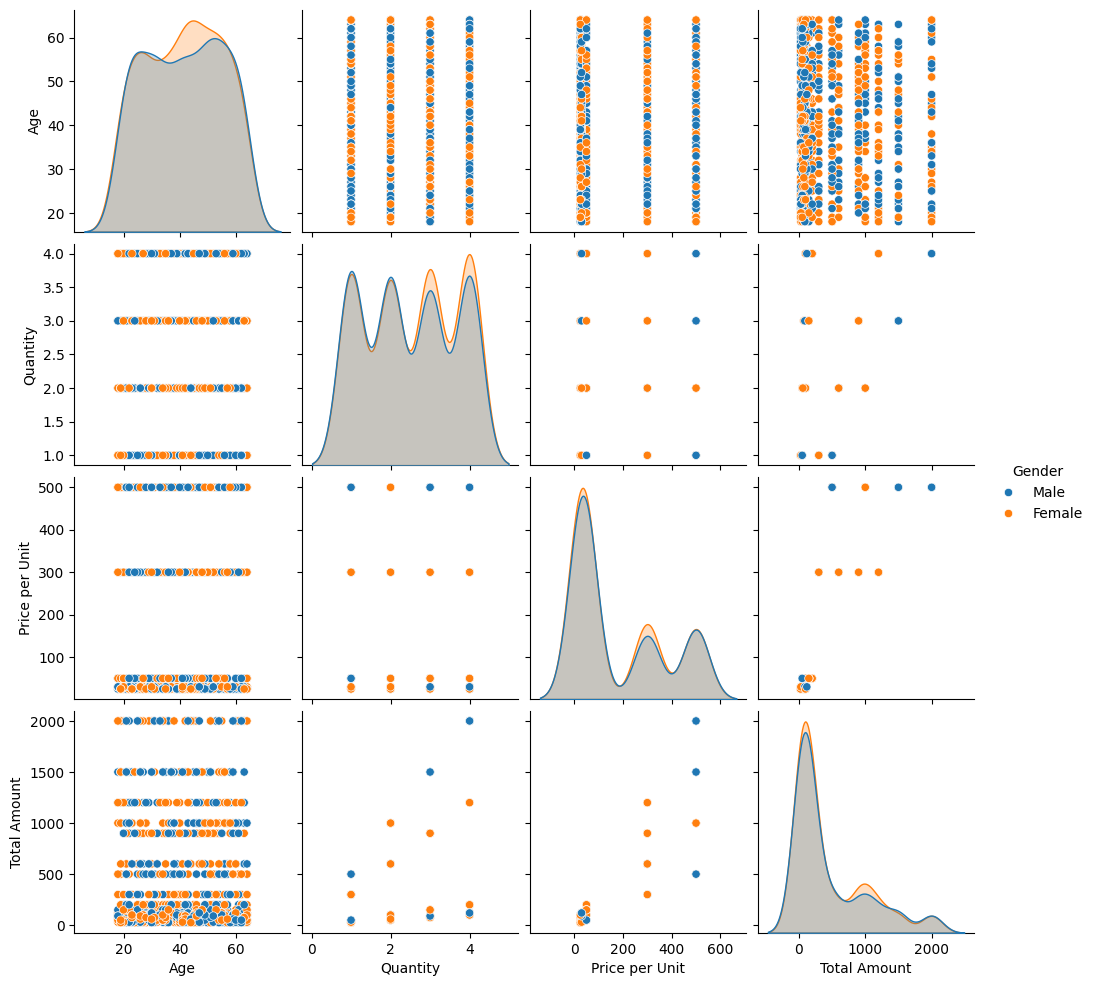

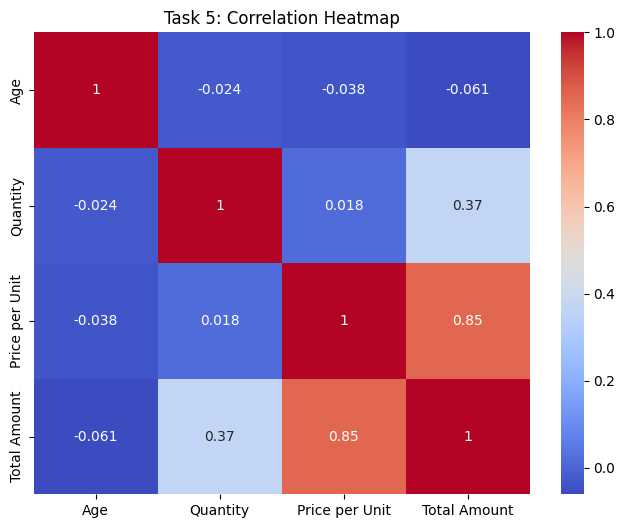

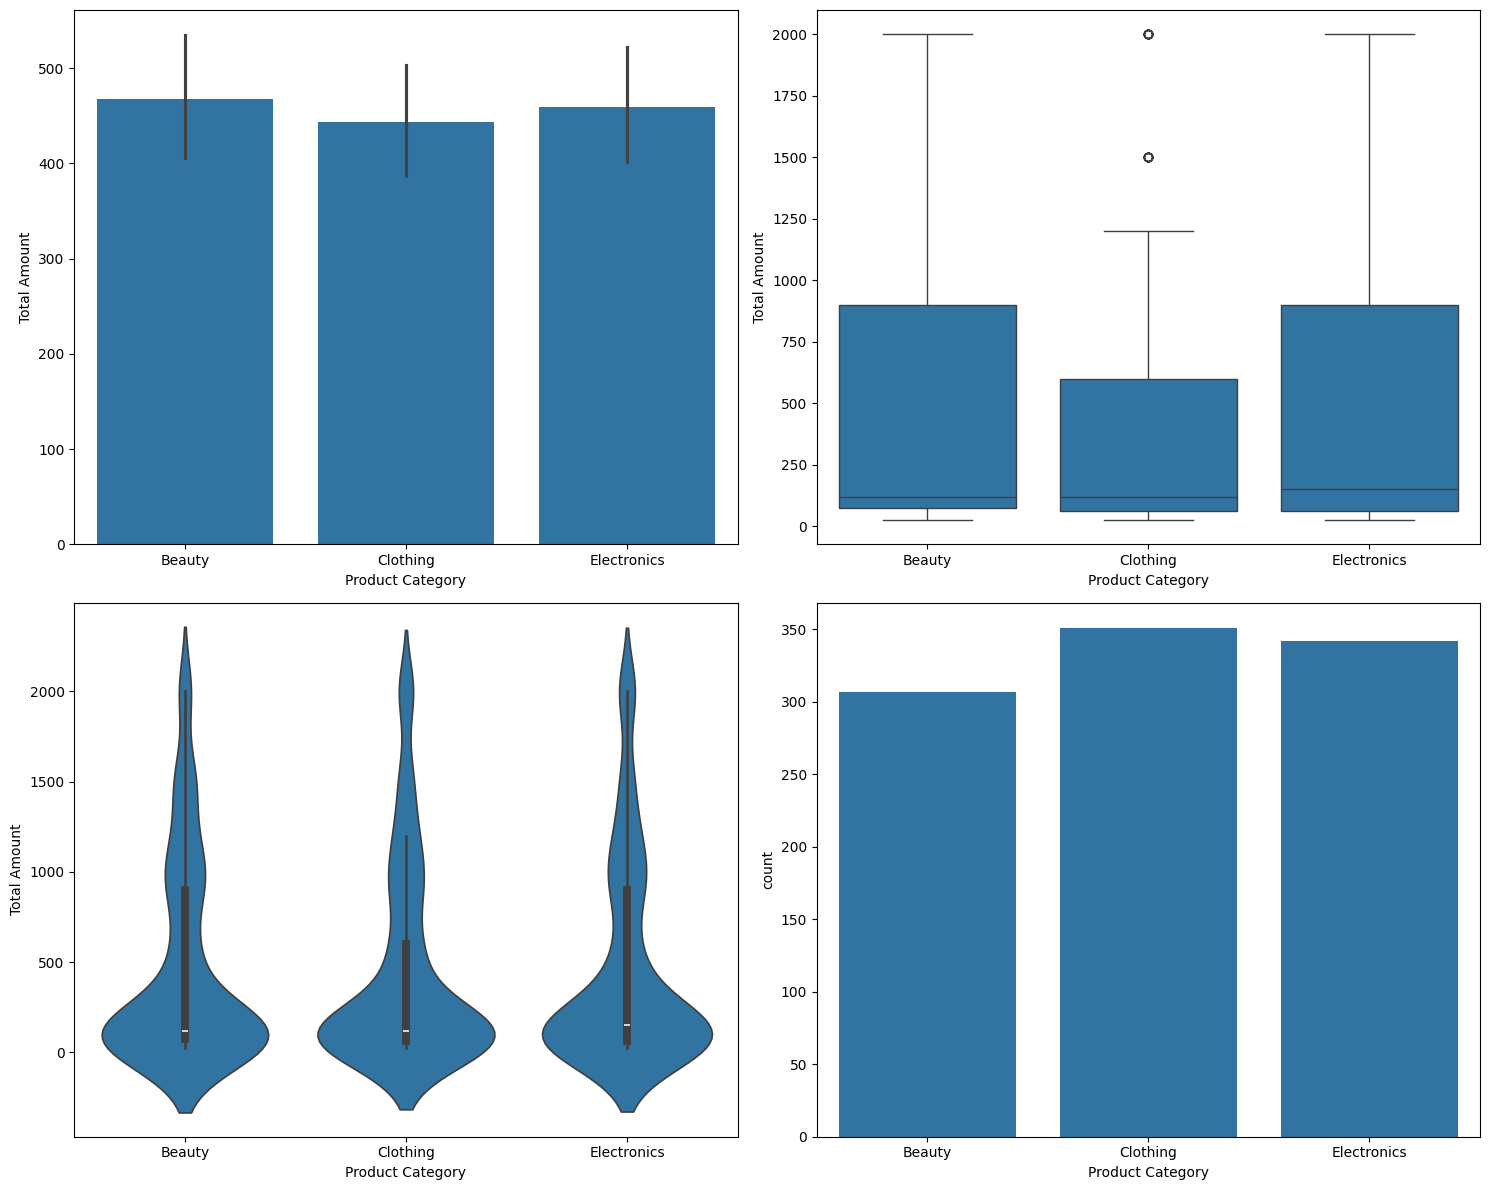

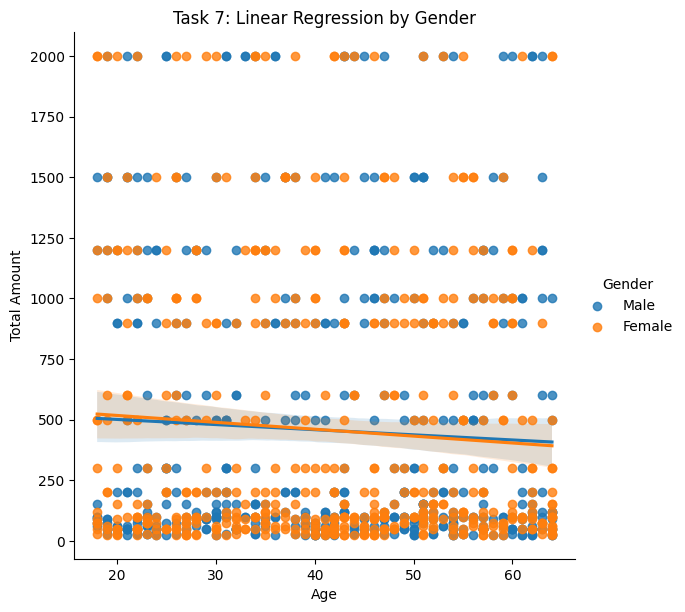

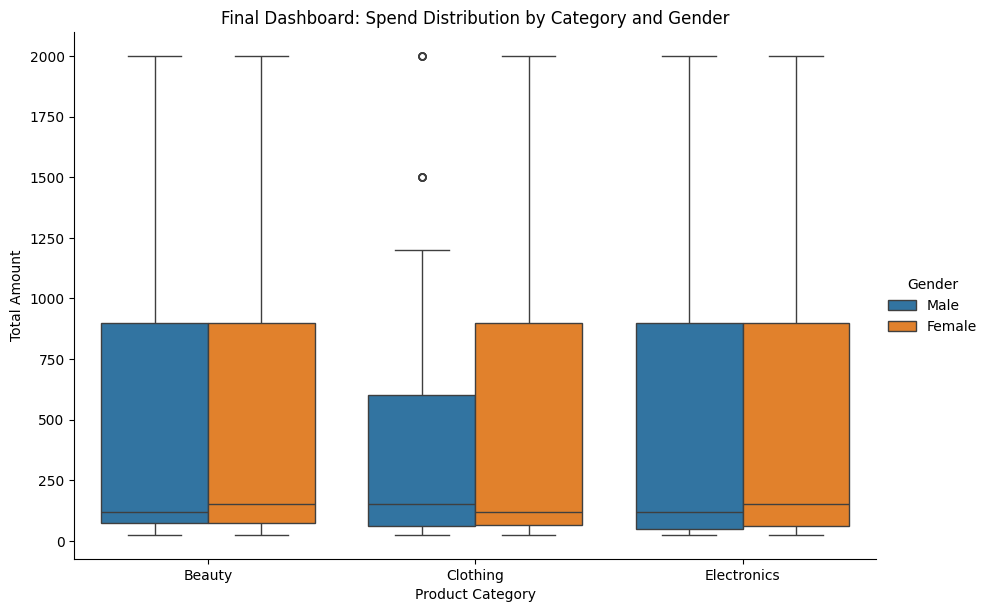

In [4]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# --- 1. Data Literacy & Exploration ---
# Recommendation 3: Demonstrating data understanding before visualization
df = pd.read_csv('retail_sales_dataset.csv')

print("--- Dataset Head ---")
print(df.head())
print("\n--- Dataset Info ---")
print(df.info())
print("\n--- Statistical Summary ---")
print(df.describe())
print("\n--- Missing Values Check ---")
print(df.isnull().sum())

# --- Task 1: Relational Plot ---
# WHEN: Use to identify the relationship/correlation between two numerical variables.
# WHY: Hue helps distinguish patterns across categories (Gender) within the numerical spread.
sns.relplot(data=df, x="Age", y="Total Amount", hue="Gender", kind="scatter", height=6, aspect=1.2)
plt.title('Task 1: Age vs Total Spend by Gender')
plt.show()

# --- Task 2: Line Plot & Faceting ---
# WHEN: Use line plots for trends; faceting is best for comparing those trends across groups.
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x="Age", y="Total Amount", marker='o')
plt.title("Task 2: Trend Analysis of Spend by Age")
plt.show()

# Faceting by Product Category
sns.relplot(data=df, x="Age", y="Total Amount", col="Product Category", kind="line", height=4)
plt.show()

# --- Task 3: Individual Distribution Plots ---
# Recommendation 1: Showing each plot type individually to demonstrate purpose.

# A. Histogram: Best for seeing the count/frequency of data in "bins".
plt.figure(figsize=(8,4))
sns.histplot(df['Total Amount'], bins=20)
plt.title("3A: Histogram (Frequency Distribution)")
plt.show()

# B. KDE: Best for seeing the smooth probability density of the variable.
plt.figure(figsize=(8,4))
sns.kdeplot(df['Total Amount'], fill=True, color="red")
plt.title("3B: KDE Plot (Density Estimation)")
plt.show()

# C. Rug Plot: Best for seeing every individual data point's location on the axis.
plt.figure(figsize=(8,2))
sns.rugplot(df['Total Amount'])
plt.title("3C: Rug Plot (Individual Data Points)")
plt.show()

# D. Combined: Shows the count, the trend line, and the raw points together.
plt.figure(figsize=(10,6))
sns.histplot(df['Total Amount'], kde=True)
sns.rugplot(df['Total Amount'])
plt.title("3D: Combined Distribution Analysis")
plt.show()

# --- Task 4: Bivariate Distribution ---
# WHEN: Use to see where the "density" of two variables overlaps.
sns.displot(data=df, x="Age", y="Total Amount", kind="kde", fill=True)
plt.title("Task 4: Bivariate Density (Age vs Amount)")
plt.show()

# --- Task 5: Matrix Plots ---
# WHEN: Use Pair Plots for a quick overview of all numerical correlations.
# Use Heatmaps for a precise mathematical look at correlations.
sns.pairplot(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount', 'Gender']], hue='Gender')
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].corr(), annot=True, cmap='coolwarm')
plt.title("Task 5: Correlation Heatmap")
plt.show()

# --- Task 6: Categorical Plots ---
# Recommendation 4: Explaining categorical comparisons.
# 
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Bar: Shows central tendency (mean).
sns.barplot(data=df, x="Product Category", y="Total Amount", ax=axes[0,0])
# Box: Shows medians and outliers (great for finding anomalies).
sns.boxplot(data=df, x="Product Category", y="Total Amount", ax=axes[0,1])
# Violin: Combines box plot with KDE to show density spread.
sns.violinplot(data=df, x="Product Category", y="Total Amount", ax=axes[1,0])
# Count: Simple frequency check of categorical occurrences.
sns.countplot(data=df, x="Product Category", ax=axes[1,1])

plt.tight_layout()
plt.show()

# --- Task 7: Regression Plots ---
# WHEN: Use to predict or visualize the linear trend between variables.
sns.lmplot(data=df, x="Age", y="Total Amount", hue="Gender", height=6)
plt.title("Task 7: Linear Regression by Gender")
plt.show()

# --- Task 8: Multi-Plot Dashboard ---
# WHEN: Use for high-level "Executive Summaries" of multiple data dimensions.
sns.catplot(data=df, x="Product Category", y="Total Amount", hue="Gender", kind="box", height=6, aspect=1.5)
plt.title("Final Dashboard: Spend Distribution by Category and Gender")
plt.show()